# The legacy pipeline: T-RECS catalog + per-source diffusion sky models

This notebook is a hands-on introduction to `glori`'s **older** simulated-sky pipeline:
building a sky model source-by-source from a cosmological source catalog, rather than
generating a whole map directly with the latent diffusion model (LDM).

**If you just want to generate simulated radio skies, you almost certainly want the
modern pipeline instead** &mdash; see [`tutorial_getting_started.ipynb`](tutorial_getting_started.ipynb)
and the main `README.md`. This notebook exists to document how the *older* approach
works, for anyone extending it, comparing against it, or curious how the group's
previous paper's method was implemented.

Background: T. Vicánek Martínez, H. W. Edler, and M. Brüggen (2025), *"Simulating
realistic radio continuum survey maps with diffusion models"*, A&A,
[arXiv:2506.11715](https://arxiv.org/abs/2506.11715).

## What this notebook covers (and what it doesn't)

This pipeline has two stages:
1. **Build a "clean" sky model** &mdash; run the T-RECS cosmological simulation to get a
   source catalog, then assemble an idealized, noise-free image by pasting individual
   source images onto that catalog's positions. **This notebook covers this stage.**
2. **Simulate a telescope observation of it** &mdash; convert that clean sky model into a
   realistic simulated LOFAR observation (visibilities, noise, imaging artifacts) by
   driving external software (DP3, DDFacet, LoSiTo). **This notebook does *not* cover
   this stage** &mdash; it's slow, needs a specific external-software environment, and is
   out of scope here. See `glori.maps.telescope_simulator.TelescopeSimulator` if you
   need it.

## A note on two bugs fixed to make this notebook possible

This pipeline's extended-source step was actually broken in the codebase until
recently: `glori.models.load.load_model()` was dead code (unconditionally raised
`NotImplementedError`, due to an unresolved circular import), and a stale attribute
access (`model.in_channels`) crashed on the raw model wrapper this pipeline uses. Both
are now fixed &mdash; see the `Known issues` section of the README for details if you hit
similar errors elsewhere in older code paths.

## 0. Setup

A few environment quirks specific to this legacy pipeline (not needed for the modern
LDM/SWIIT pipeline):
- `paths.SKY_MAP_PARENT` (where `MapMaker` writes its output) points at the original
  author's storage, which isn't group-writable. We redirect it to a local directory.
- The conda environment has `h5py` but not `pytables`, so `pandas.read_hdf()` &mdash; used
  internally to read the extended-source size distribution &mdash; doesn't work out of the
  box. We read the one column we need directly via `h5py` instead.

Neither of these affects the modern pipeline.

In [1]:
import sys
sys.path.insert(0, "/hs/fs08/data/group-brueggen/kevin/diffusion/src")

import os
import shutil
import time
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt

import glori.settings.paths as paths

# Redirect output to a local, writable directory instead of paths.SKY_MAP_PARENT
# (which points at the original author's non-group-writable storage).
LOCAL_SKY_MAPS = Path("/hs/fs08/data/group-brueggen/kevin/diffusion/workspace/artifacts/legacy_sky_maps")  # NOT "sky_maps" -- that name already exists as a symlink to the same non-writable original storage
LOCAL_SKY_MAPS.mkdir(parents=True, exist_ok=True)
paths.SKY_MAP_PARENT = LOCAL_SKY_MAPS

from glori.maps.map_maker import MapMaker
from glori.data.load import parse_dset_path

In [2]:
def read_feret_diameter_max(h5_path):
    """Read the 'feret_diameter_max' column of the 'mask_metadata' table directly via
    h5py, bypassing pandas.read_hdf() (which needs the 'pytables' package -- not
    currently in this environment)."""
    with h5py.File(h5_path, "r") as f:
        g = f["mask_metadata"]
        for i in range(10):
            items_key = f"block{i}_items"
            if items_key not in g:
                break
            items = [x.decode() for x in g[items_key][:]]
            if "feret_diameter_max" in items:
                return g[f"block{i}_values"][:, items.index("feret_diameter_max")]
    raise KeyError("feret_diameter_max not found in mask_metadata blocks")

## 1. Initialize `MapMaker` and run T-RECS

[T-RECS](https://github.com/abonaldi/TRECS) ("Tiered Radio Extragalactic Continuum
Simulation") is an external cosmological source-count simulator that ships with this
group's setup. `MapMaker.prepare_TRECS()` writes it a parameter file (field size,
frequency, random seed); `MapMaker.run_TRECS()` runs it.

We use a small 0.2&deg;&times;0.2&deg; field (the paper itself uses 5&deg;&times;5&deg;) so this
runs in seconds rather than minutes, purely for illustration.

In [3]:
MAP_NAME = "tutorial_legacy_sky"
prev = paths.SKY_MAP_PARENT / MAP_NAME
if prev.exists():
    shutil.rmtree(prev)

mm = MapMaker(
    map_name=MAP_NAME,
    map_size_deg=0.2,                        # paper uses 5.0 for production runs
    model_name="Prototypes_Model_SizeCond",  # size-conditioned DM for extended sources
    dset=None,                               # set manually below (pytables workaround)
    sampler_settings={"n_devices": 1},
)

# Manually set the extended-source size distribution (normally MapMaker.
# get_model_size_distribution() does this via pandas.read_hdf()).
feret = read_feret_diameter_max(parse_dset_path("prototypes"))
mm.model_size_distribution = np.histogram(feret, bins=100, density=True)
mm.input_data["dset"] = "prototypes"

t0 = time.time()
mm.prepare_TRECS()
proc = mm.run_TRECS()
proc.wait()
print(f"T-RECS finished in {time.time()-t0:.1f}s (returncode {proc.returncode})")

 11:33:01 (MapMaker) - INFO : MapMaker initialized.


 11:33:01 (MapMaker) - INFO : Running T-RECS...


 11:33:01 (MapMaker) - INFO : Running command: sh /hs/fs08/data/group-brueggen/kevin/diffusion/workspace/artifacts/legacy_sky_maps/tutorial_legacy_sky/trecs/trecs_run.sh


  
                T-RECS
  
Reading run parameters from parameter_file.ini
 parameters not defined in that file will be set to their default value
 Parser: freqs_file = ./frequency_list.dat
 Parser: no_AGN =            0 
 Parser: no_SFG =            0 
 Parser: sim_side =   0.20000000000000001      
 Parser: fluxlim_cont =    8.0000000000000007E-005 
 Parser: fluxlim_cont_freq =    144.00000000000000      
 Parser: save_lums =            0 
 Parser: z_min =    0.00000000     
 Parser: z_max =    8.00000000     
 Parser: outdir = .
 Parser: TRECSinputs = /hs/fs08/data/group-brueggen/tmartinez/trecs
 Parser: seed =           76 
 simulation area [square degrees]=   4.0000000000000008E-002
 /hs/fs08/data/group-brueggen/tmartinez/trecs/TRECS_Inputs/alphaeff/alphascaling_1.4_4.8.txt                                                                                                             
 /hs/fs08/data/group-brueggen/tmartinez/trecs/TRECS_Inputs/alphaeff/alphascaling_4.8_20.txt         

 ************************
 AGNs: Processing redshift   9.9999997764825821E-003  Range   0.0000000000000000        1.4999999664723873E-002
 ************************
 /hs/fs08/data/group-brueggen/tmartinez/trecs/TRECS_Inputs/AbundanceMatch/results_AGNs/AGNprob_LERG_z0.01.txt                                                                                            


...

 /hs/fs08/data/group-brueggen/tmartinez/trecs/TRECS_Inputs/AbundanceMatch/results_AGNs/AGNprob_HERG_z5.80.txt                                                                                            
 ************************
 SFGs: Processing redshift   5.8000001907348633       Range   5.7000000476837158        5.9000000953674316     
 ************************
 volume=   75393.260363372421     
 /hs/fs08/data/group-brueggen/tmartinez/trecs/TRECS_Inputs/AbundanceMatch/results_LSFR/L2mh_z5.80.txt                                                                                                    
 /hs/fs08/data/group-brueggen/tmartinez/trecs/TRECS_Inputs/results_SFR_Mstar/SFR2mstar_z5.80.txt                                                                                                         
 /hs/fs08/data/group-brueggen/tmartinez/trecs/TRECS_Inputs/SFRF/SFRF_z5.80.dat                                                                                                                     

 number of spheroids galaxies for Mpc**3   2.8378151079679013E-010
 number of lens_sphergalaxies for Mpc**3   2.1515491820687296E-009
 ************************
 AGNs: Processing redshift   7.4000000953674316       Range   7.2999999523162842        7.5000000000000000     
 ************************
 /hs/fs08/data/group-brueggen/tmartinez/trecs/TRECS_Inputs/AbundanceMatch/results_AGNs/AGNprob_LERG_z7.40.txt                                                                                            
 /hs/fs08/data/group-brueggen/tmartinez/trecs/TRECS_Inputs/AbundanceMatch/results_AGNs/AGNprob_HERG_z7.40.txt                                                                                            
 ************************
 SFGs: Processing redshift   7.4000000953674316       Range   7.2999999523162842        7.5000000000000000     
 ************************
 volume=   63292.092378822810     
 /hs/fs08/data/group-brueggen/tmartinez/trecs/TRECS_Inputs/AbundanceMatch/results_LSFR/L2mh_z7.40.t

 writing
 file            2  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z0.20.fits
 number of rows          12
 writing
 file            3  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z0.25.fits
 number of rows          11
 writing
 file            4  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z0.30.fits
 number of rows          12
 writing
 file            5  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z0.35.fits
 number of rows          10
 writing
 file            6  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z0.40.fits
 number of rows           6
 writing
 file            7  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z0.45.fits
 number of rows           7
 writing
 file            8  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z0.50.fits
 number of rows          11
 writing
 file            9  of          

 number of rows           8
 writing
 file           17  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z0.95.fits
 number of rows          13
 writing
 file           18  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z1.00.fits
 number of rows          25
 writing
 file           19  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z1.20.fits
 number of rows          17
 writing
 file           20  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z1.40.fits
 number of rows          10
 writing
 file           21  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z1.60.fits
 number of rows          20
 writing
 file           22  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z1.80.fits
 number of rows          14
 writing
 file           23  of          33
 copying catalogue./raw_continuum/catalogue_continuum_z2.00.fits
 number of rows          15
 writing
 fil

 number of rows           1
 writing
 file           33  of          33
 Total clock time [m]:   7.98333343E-03
                Wrapper > Normal completion
T-RECS finished in 8.4s (returncode 0)


## 2. The source catalog

`MapMaker.read_TRECS()` loads T-RECS's output FITS table and classifies every source as
either **compact** (rendered as a simple 2D Gaussian) or **extended** (rendered by
sampling from a separate, smaller, size-conditioned diffusion model &mdash; only steep-
spectrum AGN larger than 1 pixel qualify).

In [4]:
mm.read_TRECS()

print(f"Total sources: {len(mm.comp_df) + len(mm.ext_df)}")
print(f"  Compact (2D Gaussian):        {len(mm.comp_df)}")
print(f"  Extended (diffusion-sampled): {len(mm.ext_df)}")

mm.comp_df[["flux", "size", "x_coord", "y_coord"]].head(10)

 11:33:09 (MapMaker) - INFO : Reading T-RECS catalog from
	/hs/fs08/data/group-brueggen/kevin/diffusion/workspace/artifacts/legacy_sky_maps/tutorial_legacy_sky/trecs/catalogue_continuum_wrapped.fits...


 11:33:09 (MapMaker) - INFO : Extracting values...


 11:33:09 (MapMaker) - INFO : Filtering for flux between 0.0e+00 and 2.0e+00 Jy...


 11:33:09 (MapMaker) - INFO : Filtered 0 compact sources below min_flux and 0 above max_flux.


 11:33:09 (MapMaker) - INFO : T-RECS catalog read.


Total sources: 320
  Compact (2D Gaussian):        301
  Extended (diffusion-sampled): 19


,flux,size,x_coord,y_coord
0,0.000086,"(1.4551326036453247, 1.296623945236206)",-0.067133,0.095293
1,0.000140,"(1.8336280584335327, 1.4776687622070312)",-0.039372,0.080378
2,0.000822,"(3.0536155700683594, 1.5239747762680054)",0.061101,-0.070714
3,0.000112,"(1.3779977560043335, 0.8012071251869202)",0.068714,0.077279
4,0.000101,"(2.786968469619751, 1.2794361114501953)",-0.074303,-0.007894
5,0.000235,"(3.72294545173645, 2.9166102409362793)",0.099998,0.059043
6,0.000324,"(1.538184404373169, 0.7242095470428467)",0.066228,0.092130
7,0.000336,"(2.0586743354797363, 1.1953717470169067)",0.042786,-0.093886
8,0.000392,"(2.485018491744995, 1.5410116910934448)",0.006049,0.065137
9,0.000394,"(3.169828176498413, 1.3858858346939087)",0.090242,0.092151


## 3. Render the compact sources (2D Gaussians)

Every compact source becomes an elliptical 2D Gaussian, sized/oriented from the
catalog, convolved with a fixed 6&Prime; restoring-beam kernel, and flux-normalized. This
step is analytic (no ML), and fast even for hundreds of sources.

In [5]:
t0 = time.time()
mm.make_compact_sources_parallel()
print(f"Rendered {len(mm.comp_images)} compact sources in {time.time()-t0:.1f}s")

 11:33:09 (MapMaker) - INFO : Generating compact sources in parallel...


Submitting jobs:   0%|          | 0/301 [00:00<?, ?it/s]

Submitting jobs:   0%|          | 1/301 [00:00<01:25,  3.49it/s]

Submitting jobs: 100%|██████████| 301/301 [00:00<00:00, 970.45it/s]

Making compact sources:   0%|          | 0/301 [00:00<?, ?it/s]

Making compact sources:  83%|████████▎ | 250/301 [00:00<00:00, 2492.91it/s]

Making compact sources: 100%|██████████| 301/301 [00:00<00:00, 2780.63it/s]

Rendered 301 compact sources in 0.5s


## 4. Render the extended sources (diffusion-sampled)

This is the interesting part: for each extended source, a target angular size is drawn
from the training-data size distribution, and a **separate, smaller diffusion model**
(`Prototypes_Model_SizeCond` &mdash; an 80&times;80px, pixel-space EDM model, size-conditioned,
*not* the VQ-VAE+latent-diffusion LDM from the modern pipeline) generates its
morphology. The result is masked and flux-normalized before being placed on the sky.

We cap the number of extended sources for this demo, purely so sampling stays fast.

In [6]:
MAX_EXTENDED = 8
if len(mm.ext_df) > MAX_EXTENDED:
    print(f"Capping extended sources from {len(mm.ext_df)} to {MAX_EXTENDED} for this demo.")
    mm.ext_df = mm.ext_df.iloc[:MAX_EXTENDED].reset_index(drop=True)

t0 = time.time()
mm.make_extended_sources()
print(f"Sampled {len(mm.ext_data['images'])} extended sources in {time.time()-t0:.1f}s")

mm.ext_df[["flux", "size", "feret_diameter_max"]]

 11:33:10 (MapMaker) - INFO : Generating extended sources...


/hs/fs08/data/group-brueggen/tmartinez/envs/cenv_glori/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/hs/fs08/data/group-brueggen/tmartinez/envs/cenv_glori/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PowerTransformer from version 1.3.0 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
 11:33:10 (DMSampler) - INFO : Inferring number of samples from input shapes. Sampler settings will be changed.


 11:33:10 (DMSampler) - INFO : Sampling 8 images in total.


 11:33:10 (DMSampler) - INFO : Sampling 8 images in 1 batches of size 8.


Capping extended sources from 19 to 8 for this demo.


...

Scaling images: 100%|██████████| 8/8 [00:00<00:00, 3505.48it/s]


 11:33:28 (MapMaker) - INFO : Setting class attributes...


 11:33:28 (MapMaker) - INFO : Extended sources generated.


Sampled 8 extended sources in 18.8s


,flux,size,feret_diameter_max
0,0.000331,16.950728,18.027756
1,0.000309,24.571949,25.632011
2,0.000283,37.441078,39.000000
3,0.000241,30.615208,32.280025
4,0.000128,26.861742,27.856777
5,0.000083,23.023915,24.351591
6,0.000165,77.301057,79.755878
7,0.000943,43.161863,43.863424


## 5. Assemble the sky model

Both source types get pasted onto an initially empty array at their catalog position
&mdash; compact sources centered on the stamp, extended sources aligned by mask centroid.
The result is a **clean, noise-free sky model**: no telescope response, no noise, no
imaging artifacts. (Contrast this with the modern LDM/SWIIT pipeline, whose output
already includes realistic noise/PSF artifacts baked in, learned directly from
observations &mdash; see `tutorial_getting_started.ipynb`.)

Adding compact sources:   0%|          | 0/301 [00:00<?, ?it/s]

Adding compact sources: 100%|██████████| 301/301 [00:00<00:00, 6952.97it/s]

Adding extended sources:   0%|          | 0/8 [00:00<?, ?it/s]

Adding extended sources: 100%|██████████| 8/8 [00:00<00:00, 6861.85it/s]

Sky model shape: (480, 480)
Nonzero pixels: 94161 / 230400


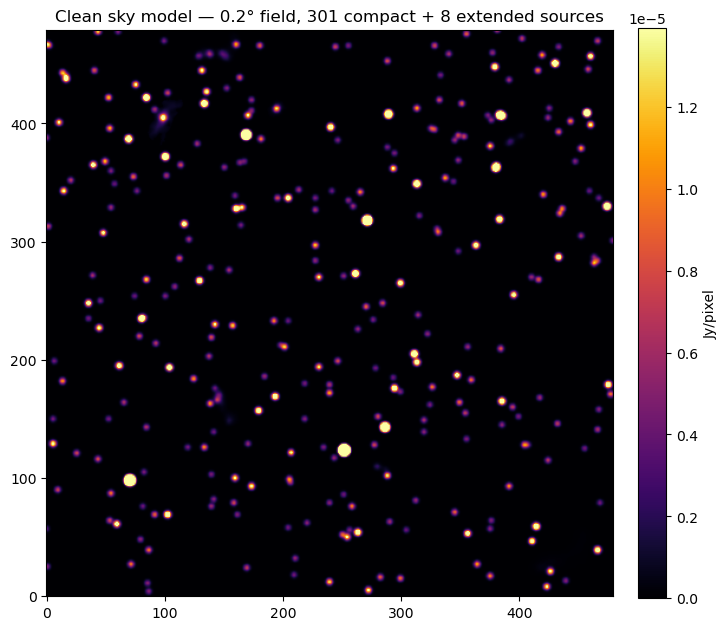

In [7]:
mm.add_compact_sources()
mm.add_extended_sources()

print("Sky model shape:", mm.map_array.shape)
print(f"Nonzero pixels: {np.count_nonzero(mm.map_array)} / {mm.map_array.size}")

fig, ax = plt.subplots(figsize=(8, 8))
vmin, vmax = np.percentile(mm.map_array, [1, 99.5])
im = ax.imshow(np.clip(mm.map_array, vmin, vmax), origin="lower", cmap="inferno")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Jy/pixel")
ax.set_title(f"Clean sky model \u2014 {mm.map_size_deg}\u00b0 field, "
             f"{len(mm.comp_df)} compact + {len(mm.ext_df)} extended sources")
plt.show()

## 6. Where to go next

- To get a **realistic, noisy simulated observation** of this sky model (the second
  half of the precursor paper's pipeline), see `glori.maps.telescope_simulator.
  TelescopeSimulator` &mdash; not covered here; it drives external LOFAR software and is
  considerably slower.
- To generate simulated skies **directly**, with realistic noise/artifacts included and
  without needing T-RECS or a telescope simulation at all, use the modern pipeline in
  [`tutorial_getting_started.ipynb`](tutorial_getting_started.ipynb) instead.
- `src/glori/maps/map_maker.py` &mdash; full `MapMaker` implementation.
- `src/glori/maps/map_utils.py` &mdash; the Gaussian-source and source-placement utilities
  used here (`gaussian_signal`, `add_source_image`, `get_source_slice`).